In [1]:
import os
os.getcwd()

'c:\\Users\\Yashasvi\\Documents\\Machine-Learning-Project\\Diabetic_Prediction'

In [2]:
os.chdir("C:/Users/Yashasvi/Documents/Machine-Learning-Project/Diabetic_Prediction")

In [3]:
import numpy as np 

import pandas as pd #excellent for dataset manupalation

# for data visulization
import matplotlib.pyplot as plt

#stats visualization
import seaborn as sns

#Labelencoding to convert categorical data into lowlevel language
from sklearn.preprocessing import LabelEncoder

#scaling data
from sklearn.preprocessing import StandardScaler

#data partions
from sklearn.model_selection import train_test_split

#algorithams
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


#accuracy confusion matric and classification report
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


import warnings

# To ignore all warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("diabetes_prediction_dataset.csv")   #Reading csv file

In [5]:
df.head() #it displace the first 5 rows

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
df.isna().any() 

gender                 False
age                    False
hypertension           False
heart_disease          False
smoking_history        False
bmi                    False
HbA1c_level            False
blood_glucose_level    False
diabetes               False
dtype: bool

In [7]:
df.corr(numeric_only=True) 

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


In [8]:
df.shape

(100000, 9)

In [9]:
for column in df.columns: # itreating each column in df.columns 
    unique_values = df[column].unique() #finding unique values of each column

    #printing unique values
    print('Column "{}" has unique values: {}'.format(column, unique_values)) 

Column "gender" has unique values: ['Female' 'Male' 'Other']
Column "age" has unique values: [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
Column "hypertension" has unique values: [0 1]
Column "heart_disease" has unique values: [1 0]
Column "smoking_history" has unique values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
Column "bmi" has unique values: [25.19 27.32 23.45 ... 59.42 44.39 60.52]
Column "HbA1c_level" h

In [10]:
df["smoking_history"].value_counts() 
#Value count of smoking _history parameter it has no info parameter

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [11]:
df["smoking_history"].value_counts()/len(df) #finding the percentage

smoking_history
No Info        0.35816
never          0.35095
former         0.09352
current        0.09286
not current    0.06447
ever           0.04004
Name: count, dtype: float64

In [12]:

# Replaceing No Info columns with pd.NA
df['smoking_history'] = df['smoking_history'].replace('No Info', pd.NA)

# Replace missing values with the mode it is string so we are using mode
mode_value = df['smoking_history'].mode()[0]
df['smoking_history'] = df['smoking_history'].fillna(mode_value) #filling no info values 

# Printing the updated value counts
print(df['smoking_history'].value_counts())


smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [13]:
df.info() #information of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [14]:
df.gender.value_counts() #Gender value_counts

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [15]:
df.describe() #descripation 

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [16]:
#removing , in bmi parameter 
df["bmi"] = [float(str(i).replace(",", "")) for i in df["bmi"]] 

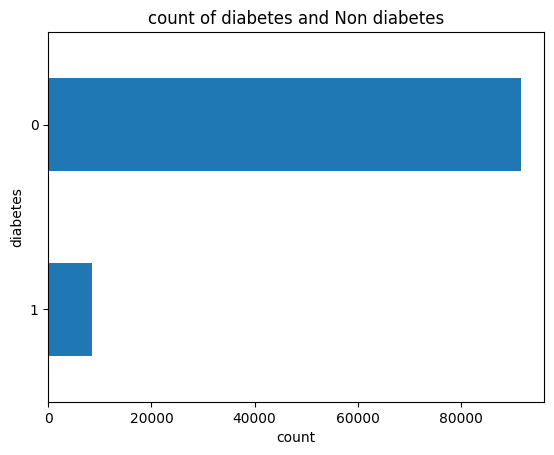

In [17]:
#ploting value_counts of diabetes in graphical representation
df['diabetes'].value_counts().plot(kind='barh') 

#Xlabel name
plt.xlabel('count')

#ylabel name
plt.ylabel('diabetes')

#title of the plot
plt.title('count of diabetes and Non diabetes')

#invert ylabes to no diabetes on top
plt.gca().invert_yaxis() 

#printing the plot
plt.show()

In [18]:
df['diabetes'].value_counts()/len(df) #percentage of 1--diabetes and 2--no diabetes 

diabetes
0    0.915
1    0.085
Name: count, dtype: float64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [20]:
le=LabelEncoder() #activating label encoder function

le

LabelEncoder()

In [21]:
Label_encod_columns=['gender','smoking_history']  #selecting columns to apply labelencoder in next step

df[Label_encod_columns]=df[Label_encod_columns].apply(le.fit_transform) #applying label encoding

In [22]:

df.head(3) # printing top 3 columns to confirm to check labelencoder 

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,3,25.19,6.6,140,0
1,0,54.0,0,0,3,27.32,6.6,80,0
2,1,28.0,0,0,3,27.32,5.7,158,0


<Axes: >

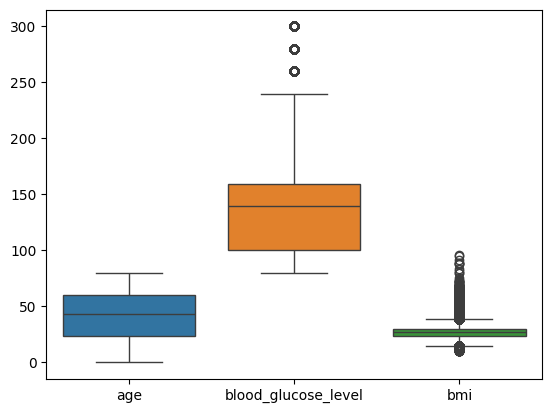

In [23]:
sns.boxplot(data=df[['age','blood_glucose_level','bmi']]) #checking outliers using boxplot

<Axes: ylabel='HbA1c_level'>

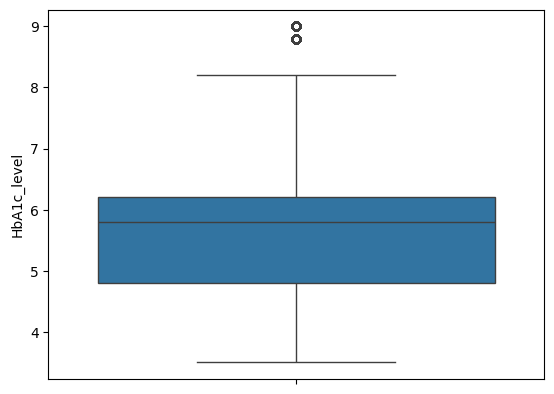

In [24]:
sns.boxplot(data=df['HbA1c_level']) #checking outlayers using boxplot

In [25]:
''' it is always good to ignore outliers in medical data '''

' it is always good to ignore outliers in medical data '

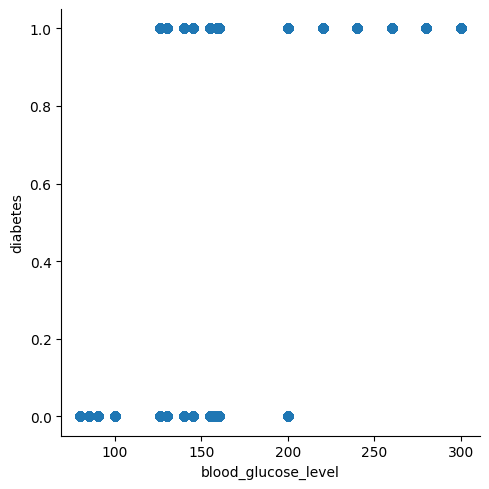

In [26]:
sns.lmplot(data=df, x='blood_glucose_level', y='diabetes', fit_reg=False)#implot plot

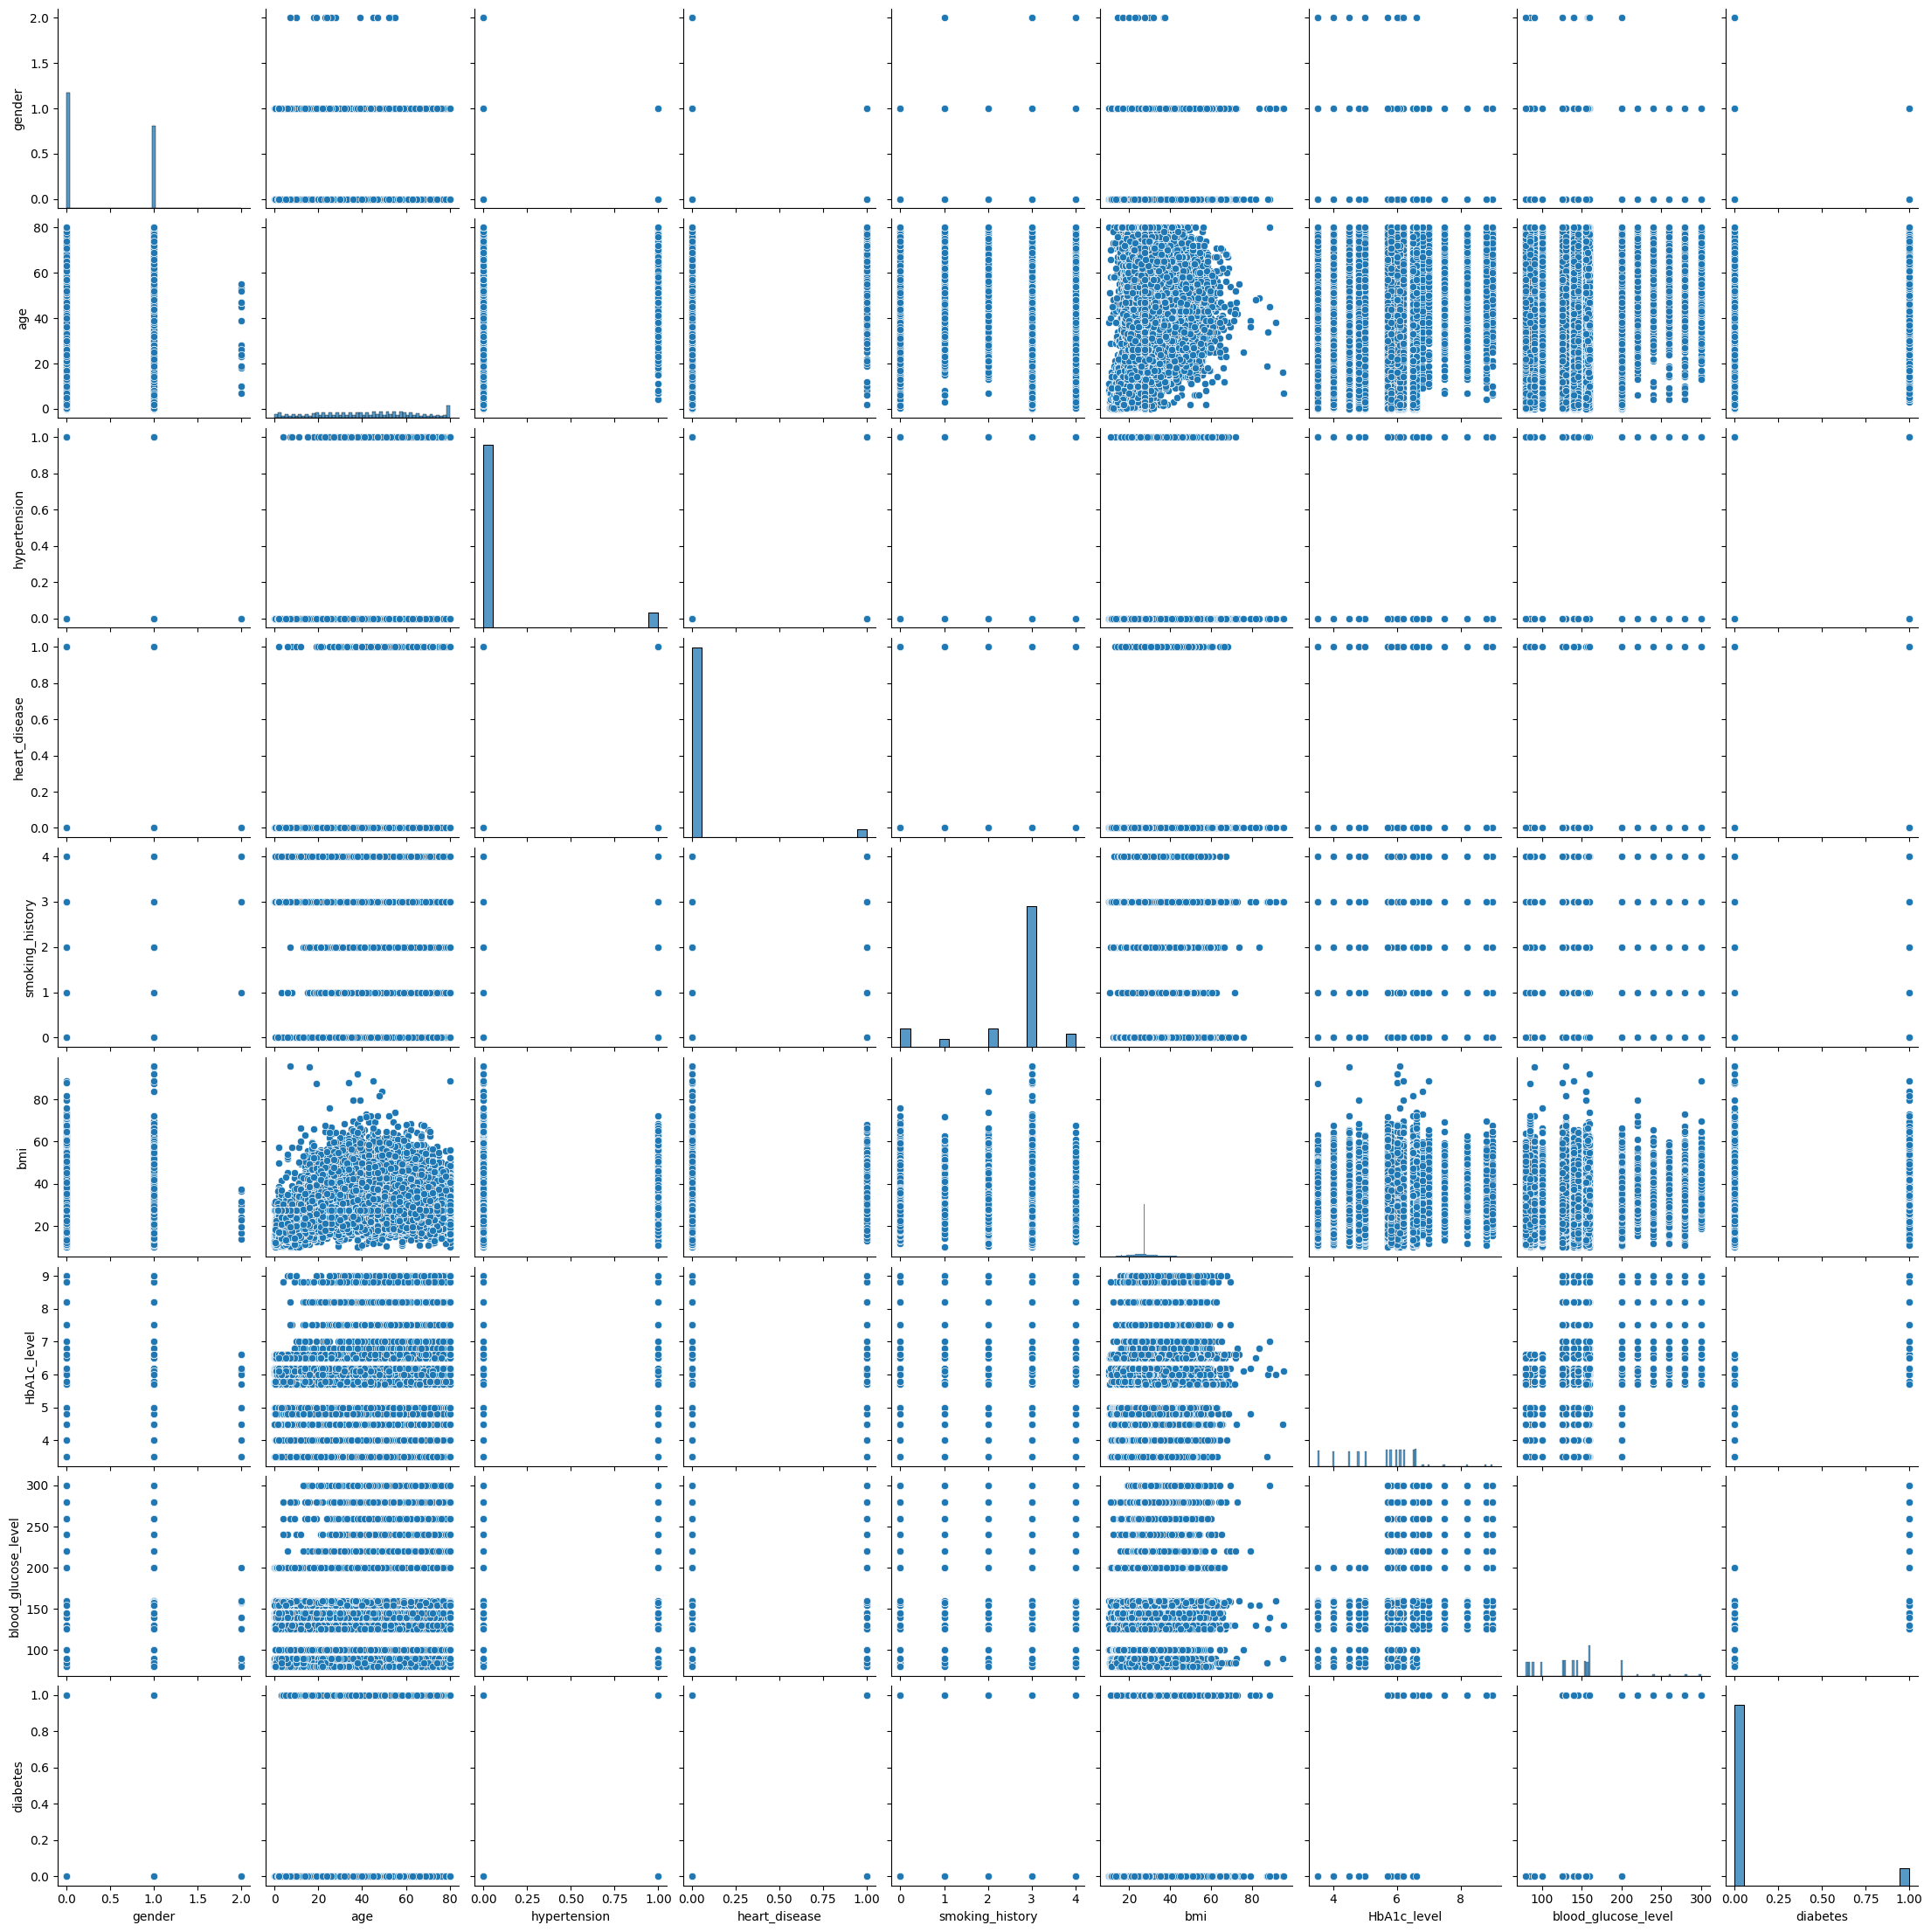

In [27]:
sns.pairplot(df) #using pairplot to check relation between parameters

#print the pairplot
plt.show()

In [28]:
'''when age increase hypertension and hert disease ,blood_glucose_level and diabetes and age  and also the is a 
   relationship between them

    *bmi
    
    *HbA1c_level
    
    *blood_glucose_level
    
    these four paramers have relationship between each other
    
    *gender and smokling history it doesnot effect on diabetes

'''

'when age increase hypertension and hert disease ,blood_glucose_level and diabetes and age  and also the is a \n   relationship between them\n\n    *bmi\n    \n    *HbA1c_level\n    \n    *blood_glucose_level\n    \n    these four paramers have relationship between each other\n    \n    *gender and smokling history it doesnot effect on diabetes\n\n'

In [29]:
df.corr()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
gender,1.000000,-0.030656,0.014203,0.077696,-0.044081,-0.022994,0.019957,0.017199,0.037411
age,-0.030656,1.000000,0.251171,0.233354,-0.098969,0.337396,0.101354,0.110672,0.258008
hypertension,0.014203,0.251171,1.000000,0.121262,-0.048631,0.147666,0.080939,0.084429,0.197823
heart_disease,0.077696,0.233354,0.121262,1.000000,-0.048253,0.061198,0.067589,0.070066,0.171727
smoking_history,-0.044081,-0.098969,-0.048631,-0.048253,1.000000,-0.087735,-0.017534,-0.022985,-0.049841
bmi,-0.022994,0.337396,0.147666,0.061198,-0.087735,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.019957,0.101354,0.080939,0.067589,-0.017534,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.017199,0.110672,0.084429,0.070066,-0.022985,0.091261,0.166733,1.000000,0.419558
diabetes,0.037411,0.258008,0.197823,0.171727,-0.049841,0.214357,0.400660,0.419558,1.000000


<Axes: >

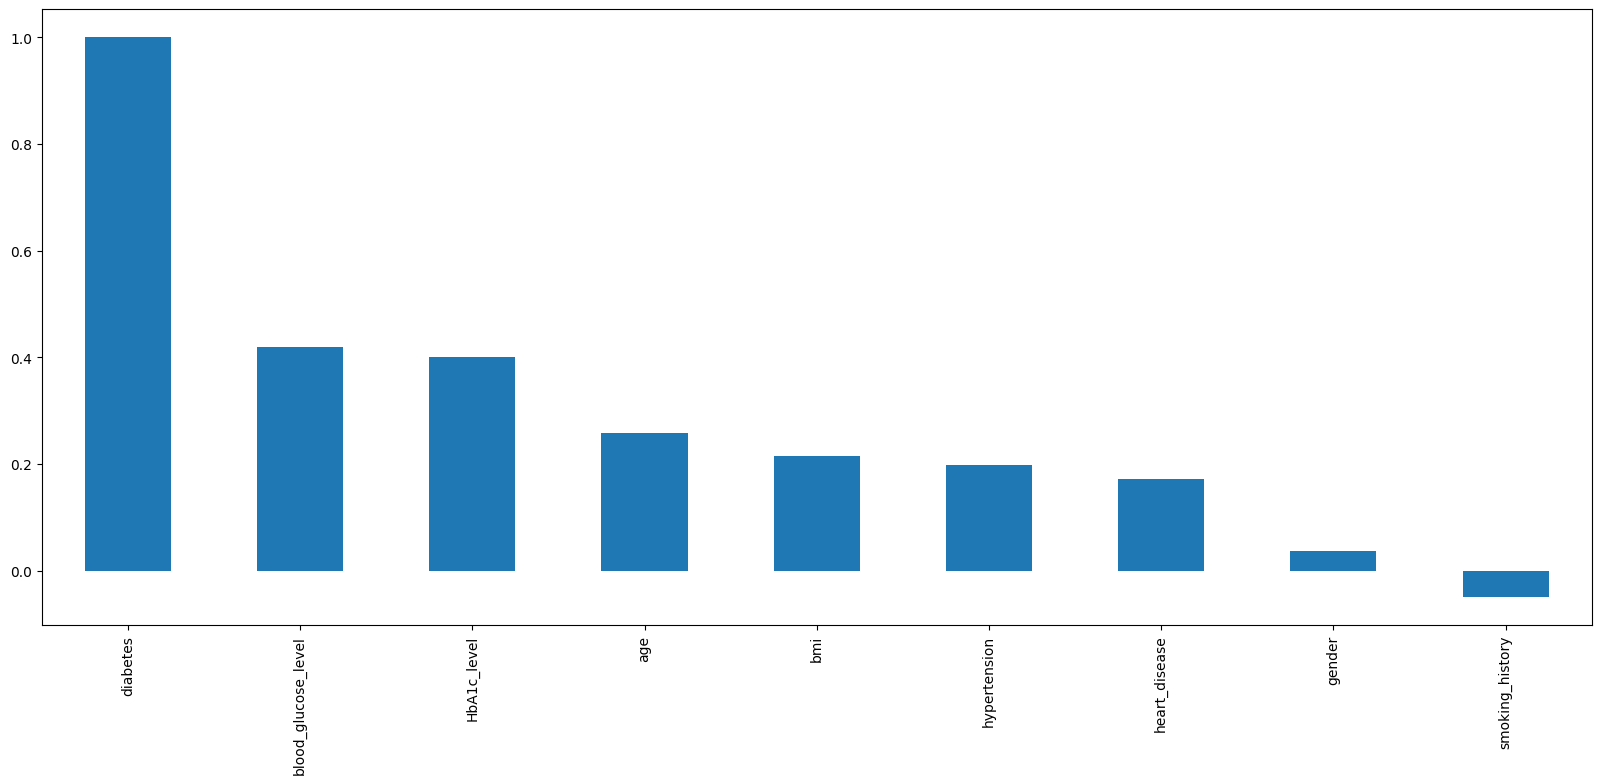

In [30]:
plt.figure(figsize=(20,8)) #figsize

#printing graphical representations of
df.corr()['diabetes'].sort_values(ascending=False).plot(kind='bar')

In [31]:

#selecting X variables
x = df.loc[:, 'age':'heart_disease'].join(df.loc[:, 'bmi':'blood_glucose_level']) 


x

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
0,80.0,0,1,25.19,6.6,140
1,54.0,0,0,27.32,6.6,80
2,28.0,0,0,27.32,5.7,158
3,36.0,0,0,23.45,5.0,155
4,76.0,1,1,20.14,4.8,155
...,...,...,...,...,...,...
99995,80.0,0,0,27.32,6.2,90
99996,2.0,0,0,17.37,6.5,100
99997,66.0,0,0,27.83,5.7,155
99998,24.0,0,0,35.42,4.0,100


In [32]:
y=df.loc[:,'diabetes']  #y variable

y #printing y variable

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 100000, dtype: int64

spliting the data

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0) #splitting data into train and test

In [34]:
x_train.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
10382,2.0,0,0,16.45,6.2,159
73171,55.0,0,0,24.59,6.0,130
30938,24.0,0,0,21.77,4.5,130
99310,30.0,0,0,27.32,6.2,159
58959,13.0,0,0,18.37,6.5,130


In [35]:
print('Shape of Train data')

print(x_train.shape)

print(y_train.shape)

print('Shape of Testing data')

print(x_test.shape)

print(y_test.shape)

Shape of Train data
(80000, 6)
(80000,)
Shape of Testing data
(20000, 6)
(20000,)


In [36]:
ss = StandardScaler() #activating standardscaler function

In [37]:
x_train_scaled=ss.fit_transform(x_train) #scaling X_train data

In [38]:
if len(x_test.shape) == 1:   #if x is 1d array
    x_test = x_test.values.reshape(-1, 1) #converting to 2d array

x_test_scaled = ss.fit_transform(x_test) #scaling x_test data

In [39]:
# logistic regression model
model_lr=LogisticRegression() #activating logistic regression model
model_lr.fit(x_train_scaled,y_train) #fitting the model with scaled data

y_pred=model_lr.predict(x_test_scaled) #predecting y_test data
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [40]:
y_test[:10]

3582     0
60498    0
53227    0
21333    0
3885     0
51521    0
84261    0
10685    1
59948    0
41032    0
Name: diabetes, dtype: int64

In [41]:
accuracy_score(y_test,y_pred) #checking accuracy of the model   

print(classification_report(y_test,y_pred)) #classification report of the model 


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18297
           1       0.86      0.63      0.73      1703

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [42]:
confusion_matrix(y_test,y_pred) #confusion matrix of the model  

array([[18114,   183],
       [  622,  1081]])

In [43]:
y_train.value_counts()#data is highly imbalance

diabetes
0    73203
1     6797
Name: count, dtype: int64

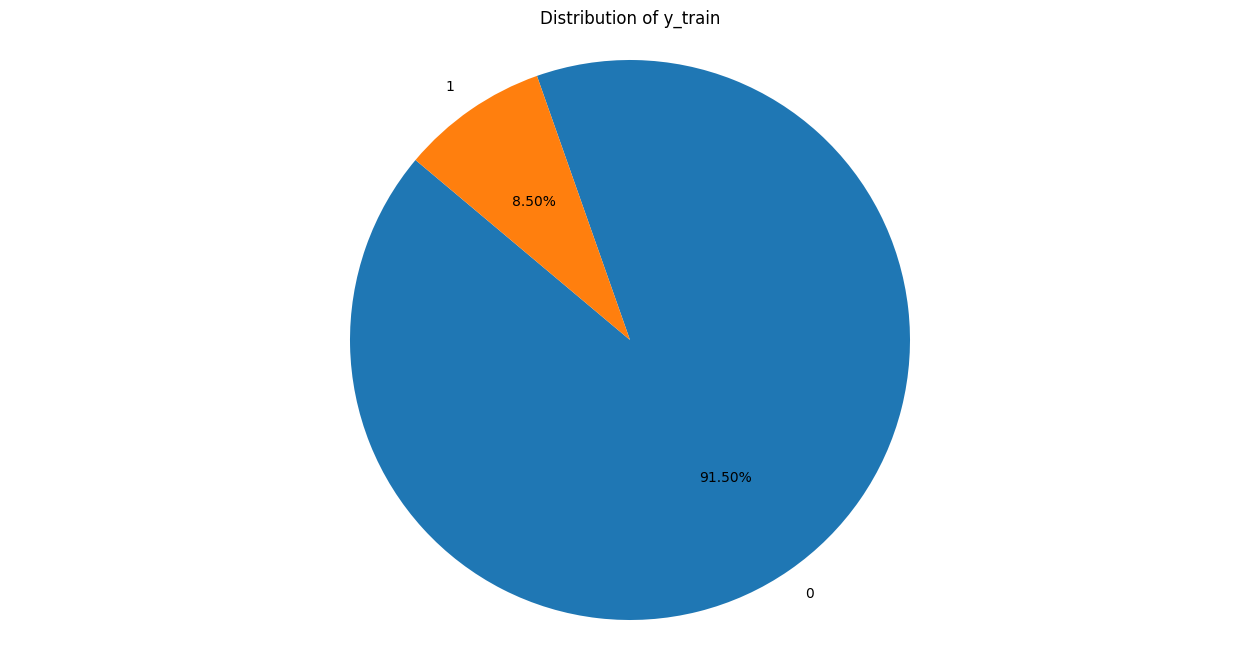

In [44]:
value_counts=y_train.value_counts()

plt.figure(figsize=(16, 8))

plt.pie(value_counts, labels=value_counts.index, autopct='%1.2f%%', startangle=140)

plt.title('Distribution of y_train')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

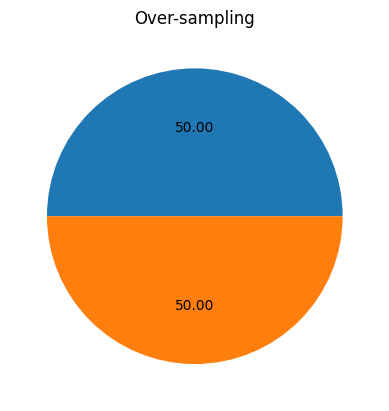

In [45]:
from imblearn.over_sampling import SMOTE # using smote function to balance our set

smote=SMOTE()

X_ovs,y_ovs=smote.fit_resample(x,y) #passing X and y variables to it to balance out data to 50 50

fig, oversp = plt.subplots() 

oversp.pie( y_ovs.value_counts(), autopct='%.2f')

oversp.set_title("Over-sampling")

plt.show()

In [46]:
# Dividing our resampling data into 70 30 ratio

Xr_train,Xr_test,yr_train,yr_test=train_test_split(X_ovs,y_ovs,train_size=0.7,random_state=42)

In [47]:
print('train data shape')

print(Xr_train.shape)

print(yr_train.shape)

print('test data shape')

print(Xr_test.shape)

print(yr_test.shape)

train data shape
(128099, 6)
(128099,)
test data shape
(54901, 6)
(54901,)


In [48]:
print('y_train and y_test value_count')
print(yr_train.value_counts())
print(yr_test.value_counts())


y_train and y_test value_count
diabetes
0    64131
1    63968
Name: count, dtype: int64
diabetes
1    27532
0    27369
Name: count, dtype: int64


In [49]:
ss=StandardScaler()

ss

,copy,True
,with_mean,True
,with_std,True


In [50]:
data=Xr_train,Xr_test



xr_train_sc=ss.fit_transform(Xr_train) # scaling our resampling data xr train


Xr_test_sc=ss.fit_transform(Xr_test) # scaling our resamplig xr_test data

In [51]:
Xr_train_scaled = pd.DataFrame(xr_train_sc) #Xr_train_scaled converting into the data frame

print(Xr_train_scaled.shape)
Xr_train_scaled.head()
print(yr_train.shape)

(128099, 6)
(128099,)


In [52]:
Xr_test_scaled=pd.DataFrame(Xr_test_sc) #Xr_test converting into the dataframe

print(Xr_test_scaled.shape)
Xr_test_scaled.head() 

(54901, 6)


,0,1,2,3,4,5
0,1.363638,-0.292649,4.913026,-0.508598,2.337025,-0.062018
1,-1.098655,-0.292649,-0.203541,-0.405685,0.375205,-0.062018
2,-1.470322,-0.292649,-0.203541,-0.288889,0.375205,-1.458461
3,-0.773447,3.417058,-0.203541,0.286939,0.375205,-1.371183
4,-1.377406,-0.292649,-0.203541,-0.288889,-2.158814,-1.109350


In [53]:
model_lk=LogisticRegression()  


model_lk.fit(Xr_train_scaled,yr_train)  #trining the model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
y_pred_lr=model_lk.predict(Xr_test_scaled) #predecting yr_test data
y_pred_lr[:10]

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 1])

In [56]:
yr_test[:10]

180328    1
573       0
13494     0
93981     0
75389     0
180973    1
71021     0
19293     0
16393     0
121419    1
Name: diabetes, dtype: int64

In [57]:
#classification_report for predict value and orginal value

print(classification_report(y_pred_lr,yr_test)) 

              precision    recall  f1-score   support

           0       0.88      0.89      0.88     27305
           1       0.89      0.88      0.88     27596

    accuracy                           0.88     54901
   macro avg       0.88      0.88      0.88     54901
weighted avg       0.88      0.88      0.88     54901



In [58]:
#confusion_matrix for predict value and orginal value

confusion_matrix(y_pred_lr,yr_test) 

array([[24165,  3140],
       [ 3204, 24392]])

DecisionTree classifire

In [59]:
# activating DecisionTree Classifier
model_dtc=DecisionTreeClassifier() 

# passing xr_train_scaled, yr_train to trining the model
model_dtc.fit(Xr_train_scaled,yr_train)

model_dtc

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [60]:
y_pred_dtc=model_dtc.predict(Xr_test_scaled) # predicting yr_test data

In [61]:
# classification report for decisionTreeclassifier

print(classification_report(y_pred_dtc,yr_test))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77     17189
           1       1.00      0.73      0.84     37712

    accuracy                           0.81     54901
   macro avg       0.81      0.86      0.81     54901
weighted avg       0.88      0.81      0.82     54901



In [62]:
confusion_matrix(y_pred_dtc,yr_test)

array([[17131,    58],
       [10238, 27474]])

RandomForestClassifier()

In [63]:
model_rfc=RandomForestClassifier() #activating the fuction

model_rfc.fit(Xr_train_scaled,yr_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_pred_rfc=model_rfc.predict(Xr_test_scaled)

In [65]:
print(classification_report(y_pred_rfc,yr_test))

              precision    recall  f1-score   support

           0       0.75      0.99      0.85     20721
           1       0.99      0.80      0.89     34180

    accuracy                           0.87     54901
   macro avg       0.87      0.90      0.87     54901
weighted avg       0.90      0.87      0.87     54901



In [66]:
confusion_matrix(y_pred_rfc,yr_test)

array([[20551,   170],
       [ 6818, 27362]])

XGBOOST

In [67]:
model_xgb=XGBClassifier()

model_xgb.fit(Xr_train_scaled,yr_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [68]:
y_pred_xgb=model_xgb.predict(Xr_test_scaled)

In [69]:
print(classification_report(y_pred_xgb,yr_test))


              precision    recall  f1-score   support

           0       0.85      0.96      0.90     23997
           1       0.97      0.86      0.91     30904

    accuracy                           0.91     54901
   macro avg       0.91      0.91      0.91     54901
weighted avg       0.92      0.91      0.91     54901



In [70]:
confusion_matrix(y_pred_xgb,yr_test)

array([[23144,   853],
       [ 4225, 26679]])

finding the hyperparameter tuning and best param grid

In [71]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search over
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'penalty': ['l1', 'l2']                # Penalty type
}

# Create a Logistic Regression model
logistic = LogisticRegression()

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=logistic, param_grid=param_grid, cv=10)

# Initialize an empty list to store the accuracy scores
accuracy_scores = []

# Perform cross-validation 10 times
for _ in range(10):
    # Fit the GridSearchCV object to the training data
    grid_search.fit(Xr_train_scaled, yr_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_
    
    # Perform cross-validation with the best model
    cv_scores = cross_val_score(grid_search.best_estimator_, Xr_train_scaled, yr_train, cv=10)
    
    # Store the mean accuracy score
    accuracy_scores.append(cv_scores.mean())

# Print the accuracy scores obtained over 10 iterations
#print("Accuracy scores over 10 iterations:", accuracy_scores)
print("Accuracy scores over 10 iterations:", ["{:.2f}".format(score) for score in accuracy_scores])


# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters found:", best_params)
print("Best cross-validation score:", best_score)


Accuracy scores over 10 iterations: ['0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89']
Best parameters found: {'C': 0.001, 'penalty': 'l2'}
Best cross-validation score: 0.8850264161573065


FINAL MODEL

In [72]:
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model with the best parameters
final_model = LogisticRegression(C=0.001, penalty='l2')

# Fit the final model to the entire training dataset
final_model.fit(Xr_train_scaled, yr_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [73]:
import pickle

# Save the final model to a pickle file
with open('final_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

In [74]:
import pickle
import numpy as np

# Load the model from the pickle file
with open('final_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Define the mean and standard deviation of the training data
mean_values = [41.885856, 0.07485, 0.03942, 27.320767, 5.527507, 138.058060]
std_values = [22.516840, 0.26315, 0.194593, 6.636783, 1.070672, 40.708136]

# Define the input features for prediction
age = 30
hypertension = 0
heart_disease = 0
bmi = 100.0
HbA1c_level = 5.0
blood_glucose_level = 90

# Scale the input features manually
scaled_features = [(x - mean) / std for x, mean, std in zip(
    [age, hypertension, heart_disease, bmi, HbA1c_level, blood_glucose_level],
    mean_values, std_values
)]

# Make predictions on the scaled data
prediction = loaded_model.predict([scaled_features])

# Print the prediction
if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")


Diabetic
